# HemaVision — Blood Cell Classification

Deep-learning classification of microscopic white blood-cell images into:

- Eosinophil
- Lymphocyte
- Monocyte
- Neutrophil

Model: EfficientNet-B0  
Framework: PyTorch  
Explainability: Grad-CAM

Dataset: Blood Cell Images by Paul Mooney, Kaggle  
https://www.kaggle.com/datasets/paultimothymooney/blood-cells

> Educational and research use only. This project is not intended for clinical diagnosis.

# Imports

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split

# Reproducibility

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


# Check GPU

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


# Dataset paths

In [4]:
DATA_ROOT = Path(
    "../data/raw/dataset2-master/dataset2-master/images"
)

TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR = DATA_ROOT / "TEST"
TEST_SIMPLE_DIR = DATA_ROOT / "TEST_SIMPLE"

print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())
print("Test simple exists:", TEST_SIMPLE_DIR.exists())

Train exists: True
Test exists: True
Test simple exists: True


# Read class names

In [5]:
class_names = sorted([
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
])

class_names

['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

# Count images

In [6]:
def count_images(directory):
    counts = {}

    for class_name in class_names:
        class_dir = directory / class_name

        images = list(class_dir.glob("*.jpeg"))
        counts[class_name] = len(images)

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN:", train_counts)
print("TEST:", test_counts)

TRAIN: {'EOSINOPHIL': 2497, 'LYMPHOCYTE': 2483, 'MONOCYTE': 2478, 'NEUTROPHIL': 2499}
TEST: {'EOSINOPHIL': 623, 'LYMPHOCYTE': 620, 'MONOCYTE': 620, 'NEUTROPHIL': 624}


# Visualize class distribution

In [7]:
df_counts = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

df_counts

,Train,Test
EOSINOPHIL,2497,623
LYMPHOCYTE,2483,620
MONOCYTE,2478,620
NEUTROPHIL,2499,624


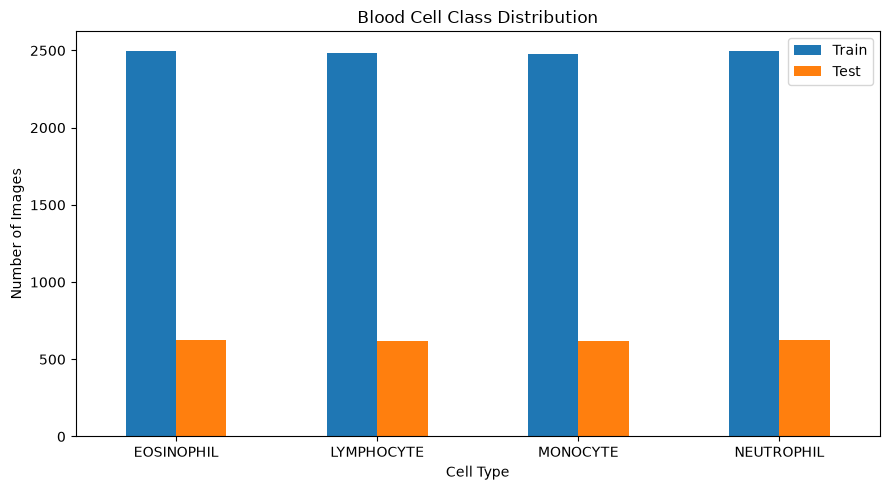

In [8]:
df_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Blood Cell Class Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display microscope images

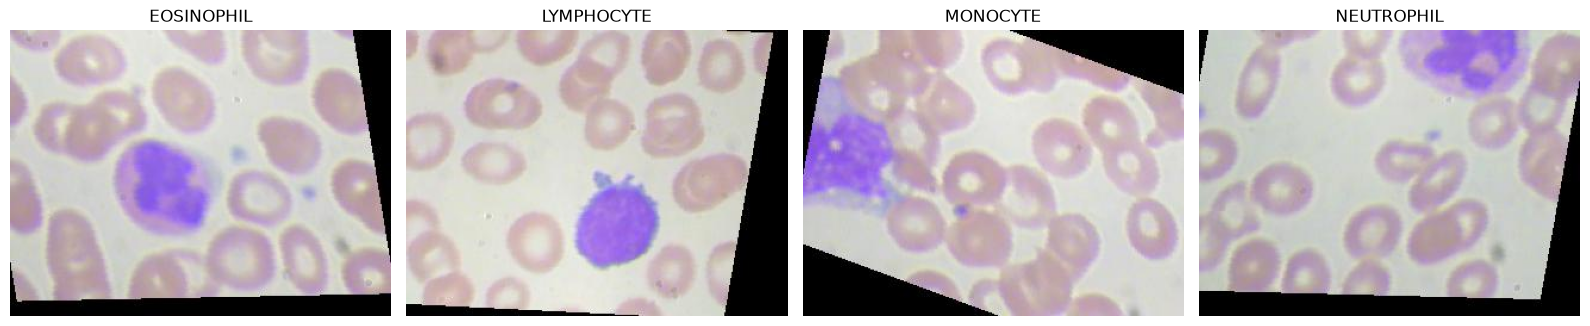

In [9]:
fig, axes = plt.subplots(
    1,
    len(class_names),
    figsize=(16, 4)
)

for ax, class_name in zip(axes, class_names):

    class_dir = TRAIN_DIR / class_name
    image_path = random.choice(list(class_dir.glob("*.jpeg")))

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Inspect image sizes

In [10]:
sizes = []

for class_name in class_names:

    paths = list(
        (TRAIN_DIR / class_name).glob("*.jpeg")
    )

    for path in paths[:100]:

        with Image.open(path) as img:
            sizes.append(img.size)

from collections import Counter

Counter(sizes).most_common(10)

[((320, 240), 400)]

# Define image preprocessing

In [11]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created.")

Transforms created.


# Create base dataset

In [12]:
from torchvision.datasets import ImageFolder

base_train_dataset = ImageFolder(
    root=TRAIN_DIR
)

print("Total training images:", len(base_train_dataset))
print("Classes:", base_train_dataset.classes)
print("Class mapping:", base_train_dataset.class_to_idx)

Total training images: 9957
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Class mapping: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


# Stratified train/validation split

In [13]:
targets = np.array(base_train_dataset.targets)

indices = np.arange(len(targets))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.15,
    random_state=SEED,
    stratify=targets
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))

Training images: 8463
Validation images: 1494


In [14]:
print(
    len(train_indices) + len(val_indices)
)

9957


# Verify stratification

In [15]:
from collections import Counter

train_labels = targets[train_indices]
val_labels = targets[val_indices]

print("Train distribution:")
print(Counter(train_labels))

print("\nValidation distribution:")
print(Counter(val_labels))

Train distribution:
Counter({np.int64(3): 2124, np.int64(0): 2122, np.int64(1): 2111, np.int64(2): 2106})

Validation distribution:
Counter({np.int64(0): 375, np.int64(3): 375, np.int64(1): 372, np.int64(2): 372})


In [16]:
idx_to_class = {
    value: key
    for key, value in base_train_dataset.class_to_idx.items()
}

print("\nTraining:")
for label, count in sorted(Counter(train_labels).items()):
    print(idx_to_class[label], count)

print("\nValidation:")
for label, count in sorted(Counter(val_labels).items()):
    print(idx_to_class[label], count)


Training:
EOSINOPHIL 2122
LYMPHOCYTE 2111
MONOCYTE 2106
NEUTROPHIL 2124

Validation:
EOSINOPHIL 375
LYMPHOCYTE 372
MONOCYTE 372
NEUTROPHIL 375


# Create separate datasets

In [17]:
train_full_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_full_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=val_test_transform
)

In [18]:
from torch.utils.data import Subset

train_dataset = Subset(
    train_full_dataset,
    train_indices
)

val_dataset = Subset(
    val_full_dataset,
    val_indices
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 8463
Validation: 1494


# Load the untouched test set

In [19]:
test_dataset = ImageFolder(
    root=TEST_DIR,
    transform=val_test_transform
)

print("Test images:", len(test_dataset))
print("Test classes:", test_dataset.classes)

Test images: 2487
Test classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


# Verify class mappings match

In [20]:
print(
    "Train mapping:",
    train_full_dataset.class_to_idx
)

print(
    "Test mapping:",
    test_dataset.class_to_idx
)

assert (
    train_full_dataset.class_to_idx
    ==
    test_dataset.class_to_idx
)

print("\nClass mappings match ✓")

Train mapping: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}
Test mapping: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}

Class mappings match ✓


# Create DataLoaders

In [21]:
BATCH_SIZE = 32

In [22]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 265
Validation batches: 47
Test batches: 78


# Inspect one batch

In [23]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Labels: tensor([1, 1, 3, 0, 2, 3, 2, 0, 0, 2])


# Visualize augmented training images

In [27]:
mean = np.array(
    [0.485, 0.456, 0.406]
)

std = np.array(
    [0.229, 0.224, 0.225]
)


def denormalize(image):
    image = image.numpy().transpose((1, 2, 0))

    image = std * image + mean

    image = np.clip(
        image,
        0,
        1
    )

    return image

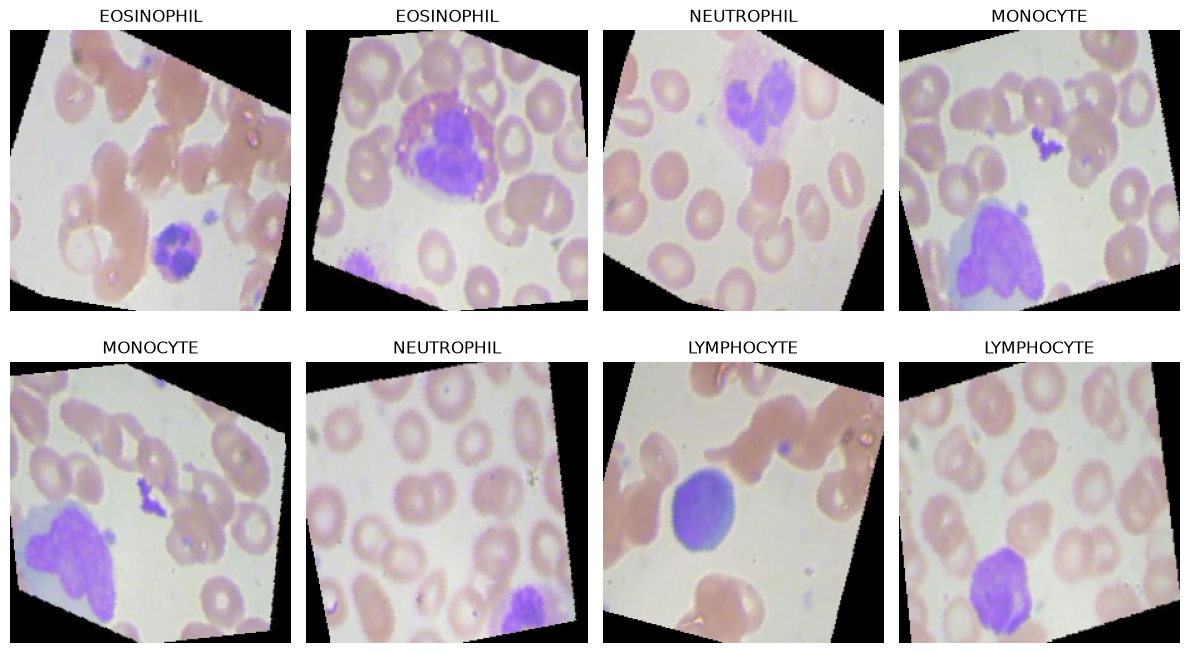

In [28]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 7)
)

for i, ax in enumerate(axes.flat):

    image = denormalize(images[i])

    label = labels[i].item()

    ax.imshow(image)

    ax.set_title(
        idx_to_class[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Import EfficientNet

In [29]:
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

# Load pretrained weights

In [30]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

print("EfficientNet-B0 loaded successfully")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\gamag/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:12<00:00, 1.74MB/s]


EfficientNet-B0 loaded successfully


# Look at the original classifier

In [31]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


# Replace the classifier

In [32]:
NUM_CLASSES = len(class_names)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


# Freeze the backbone

In [33]:
for param in model.features.parameters():
    param.requires_grad = False

In [34]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 4,012,672
Trainable parameters: 5,124


# Move model to GPU

In [35]:
model = model.to(device)

print("Model device:")
print(next(model.parameters()).device)

Model device:
cuda:0


# Define loss function

In [36]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


# Define optimizer

In [38]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

# Add learning-rate scheduler

In [39]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

# Test a forward pass

In [40]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:")
print(images.shape)

print("\nOutput shape:")
print(outputs.shape)

print("\nLabels shape:")
print(labels.shape)

Input shape:
torch.Size([32, 3, 224, 224])

Output shape:
torch.Size([32, 4])

Labels shape:
torch.Size([32])


# Inspect one prediction

In [41]:
probabilities = torch.softmax(
    outputs,
    dim=1
)

predictions = torch.argmax(
    probabilities,
    dim=1
)

print("Predicted indices:")
print(predictions[:10])

print("\nActual indices:")
print(labels[:10])

Predicted indices:
tensor([3, 0, 0, 1, 1, 2, 2, 3, 1, 3], device='cuda:0')

Actual indices:
tensor([3, 1, 0, 0, 2, 2, 3, 0, 1, 0], device='cuda:0')


# Convert prediction to class name

In [42]:
sample_prediction = predictions[0].item()
sample_actual = labels[0].item()

print(
    "Predicted:",
    idx_to_class[sample_prediction]
)

print(
    "Actual:",
    idx_to_class[sample_actual]
)

Predicted: NEUTROPHIL
Actual: NEUTROPHIL


# Verify probability sum

In [43]:
print(
    probabilities[0]
)

print(
    "Probability sum:",
    probabilities[0].sum().item()
)

tensor([0.2369, 0.2437, 0.2357, 0.2837], device='cuda:0')
Probability sum: 1.0


# Create a place to save the best model

In [44]:
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "efficientnet_b0_stage1_best.pth"

print(BEST_MODEL_PATH)

..\models\efficientnet_b0_stage1_best.pth


# Prepare history tracking

In [45]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

# Training function

In [46]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):
    model.train()

    # Backbone is frozen during Stage 1.
    # Keep its BatchNorm layers in evaluation mode.
    model.features.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predictions = torch.max(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Validation function

In [47]:
def validate(
    model,
    dataloader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predictions = torch.max(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Set training configuration

In [48]:
NUM_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 3

# Train

In [49]:
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS}"
    )

    print("-" * 50)

    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc = validate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_acc
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Accuracy:   {val_acc:.4f}"
    )

    # Update scheduler
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        epochs_without_improvement = 0

        checkpoint = {
            "architecture": "efficientnet_b0",
            "stage": 1,
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_to_idx": train_full_dataset.class_to_idx,
            "image_size": IMG_SIZE,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        print(
            "✓ Best model saved"
        )

    else:

        epochs_without_improvement += 1

        print(
            "No validation improvement."
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


Epoch 1/5
--------------------------------------------------
Train Loss: 0.9167 | Train Accuracy: 0.6525
Val Loss:   0.6904 | Val Accuracy:   0.7938
✓ Best model saved

Epoch 2/5
--------------------------------------------------
Train Loss: 0.6160 | Train Accuracy: 0.7890
Val Loss:   0.5521 | Val Accuracy:   0.8467
✓ Best model saved

Epoch 3/5
--------------------------------------------------
Train Loss: 0.5169 | Train Accuracy: 0.8219
Val Loss:   0.4642 | Val Accuracy:   0.8681
✓ Best model saved

Epoch 4/5
--------------------------------------------------
Train Loss: 0.4519 | Train Accuracy: 0.8492
Val Loss:   0.4197 | Val Accuracy:   0.8695
✓ Best model saved

Epoch 5/5
--------------------------------------------------
Train Loss: 0.4192 | Train Accuracy: 0.8567
Val Loss:   0.3971 | Val Accuracy:   0.8688
✓ Best model saved


# Plot Stage-1 curves

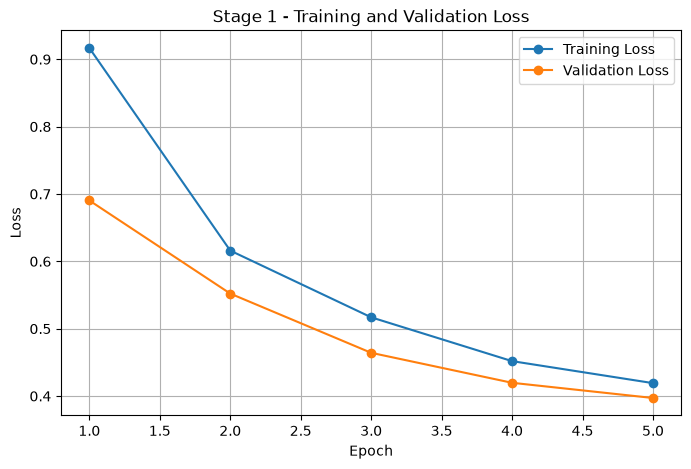

In [50]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 - Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

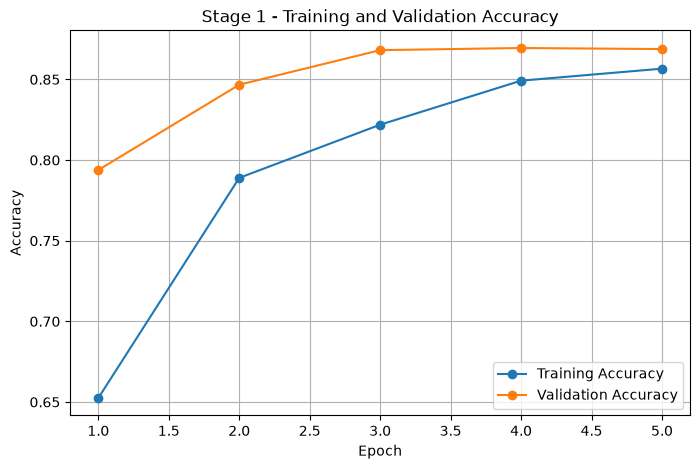

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stage 1 - Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Check saved checkpoint

In [52]:
print(
    "Model exists:",
    BEST_MODEL_PATH.exists()
)

print(
    "Model size:",
    round(
        BEST_MODEL_PATH.stat().st_size
        / (1024 ** 2),
        2
    ),
    "MB"
)

Model exists: True
Model size: 15.64 MB
